# Academic Paper Recommendation

## 1. Introduction

This study investigates academic paper recommendation using a fixed dataset pipeline generated from arXiv and OpenAlex sources. The `academic-paper-recommendation.ipynb` notebook focuses on downstream implementation and evaluation: data loading, exploration, cleaning, preprocessing/indexing, embedding, evaluation with standard IR metrics, and embedding geometry analysis.

### Objectives

1. Define and justify a methodology for building a domain-specific AI/ML corpus from arXiv.
2. Construct and document an enrichment workflow using OpenAlex metadata and citation signals.
3. Analyse data quality and corpus characteristics to identify strengths, biases, and risks to validity.
4. Build query and qrels resources suitable for reproducible offline evaluation.
5. Implement and evaluate recommendation approaches using standard IR metrics and comparative analysis.
6. Provide critical appraisal of outcomes, limitations, and actionable directions for further work.

In [3]:
# =========================================================
# Import required libraries
# =========================================================
import json
import os
import time
import math
import gc
from collections import Counter, defaultdict
from dataclasses import dataclass, asdict
from typing import Dict, List, Tuple

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.feature_extraction.text import TfidfVectorizer, ENGLISH_STOP_WORDS
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.decomposition import PCA
from sklearn.preprocessing import normalize

from sentence_transformers import SentenceTransformer

try:
    import umap
except ImportError:
    umap = None

/Users/ayomideolakulehin/mambaforge/envs/msc-paper-recommendation/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [4]:
# =========================================================
# Configuration
# =========================================================

DATA_DIR = "data"
OUTPUT_DIR = "outputs"
FIGURES_DIR = os.path.join(OUTPUT_DIR, "figures")
TABLES_DIR = os.path.join(OUTPUT_DIR, "tables")
METRICS_DIR = os.path.join(OUTPUT_DIR, "metrics")

PAPERS_PATH = os.path.join(DATA_DIR, "openalex_enriched.jsonl")
DATASET_METADATA_PATH = os.path.join(DATA_DIR, "dataset_metadata.json")
QUERIES_PATH = os.path.join(DATA_DIR, "queries.jsonl")
QRELS_PATH = os.path.join(DATA_DIR, "qrels.jsonl")

TARGET_PRIMARY_CATEGORIES = {"cs.LG", "cs.CL", "cs.AI", "stat.ML"}
OTHER_CATEGORY_LABEL = "cross_listed_non_primary"

SBERT_MODEL_NAME = "all-MiniLM-L6-v2"
TOP_K_VALUES = [5, 10, 20]
RANDOM_SEED = 70

# Benchmarking controls for more stable latency measurements.
LATENCY_WARMUP_RUNS = 1
LATENCY_REPEAT_RUNS = 5

HYBRID_ALPHA = 0.5
TWO_STAGE_CANDIDATE_SIZE = 100

os.makedirs(FIGURES_DIR, exist_ok=True)
os.makedirs(TABLES_DIR, exist_ok=True)
os.makedirs(METRICS_DIR, exist_ok=True)

## 2. Functions

Functions used re-used in this experiment are added to this section

### Utilities

In [5]:
def load_jsonl(path: str) -> List[Dict]:
    records = []
    with open(path, "r", encoding="utf-8") as f:
        for line in f:
            line = line.strip()
            if line:
                records.append(json.loads(line))
    return records

def load_json(path: str) -> Dict:
    with open(path, "r", encoding="utf-8") as f:
        return json.load(f)


def save_json(data: Dict, path: str) -> None:
    with open(path, "w", encoding="utf-8") as f:
        json.dump(data, f, indent=2, ensure_ascii=False)


def save_dataframe(df: pd.DataFrame, path: str) -> None:
    df.to_csv(path, index=False)


def normalise_whitespace(text: str) -> str:
    return " ".join(text.split()).strip()


def to_experiment_category(primary_category: str) -> str:
    return primary_category if primary_category in TARGET_PRIMARY_CATEGORIES else OTHER_CATEGORY_LABEL

@dataclass
class CorpusIndex:
    paper_ids: List[str]
    texts: List[str]
    tfidf_vectorizer: TfidfVectorizer = None
    tfidf_matrix: np.ndarray = None
    dense_model: SentenceTransformer = None
    dense_matrix: np.ndarray = None

### Evaluation Metrics Functions

In [6]:
def precision_at_k(ranked_ids: List[str], relevant_ids: set, k: int) -> float:
    top_k = ranked_ids[:k]
    if not top_k:
        return 0.0
    hits = sum(1 for doc_id in top_k if doc_id in relevant_ids)
    return hits / k


def recall_at_k(ranked_ids: List[str], relevant_ids: set, k: int) -> float:
    top_k = ranked_ids[:k]
    if not relevant_ids:
        return 0.0
    hits = sum(1 for doc_id in top_k if doc_id in relevant_ids)
    return hits / len(relevant_ids)


def reciprocal_rank(ranked_ids: List[str], relevant_ids: set) -> float:
    for i, doc_id in enumerate(ranked_ids, start=1):
        if doc_id in relevant_ids:
            return 1.0 / i
    return 0.0


def dcg_at_k(ranked_ids: List[str], relevant_ids: set, k: int) -> float:
    dcg = 0.0
    for i, doc_id in enumerate(ranked_ids[:k], start=1):
        rel = 1 if doc_id in relevant_ids else 0
        if rel > 0:
            dcg += rel / math.log2(i + 1)
    return dcg


def ndcg_at_k(ranked_ids: List[str], relevant_ids: set, k: int) -> float:
    dcg = dcg_at_k(ranked_ids, relevant_ids, k)
    ideal_count = min(len(relevant_ids), k)
    if ideal_count == 0:
        return 0.0
    ideal_ids = [1] * ideal_count
    idcg = sum(rel / math.log2(i + 1) for i, rel in enumerate(ideal_ids, start=1))
    return dcg / idcg if idcg > 0 else 0.0

### Experiment Runner

In [7]:
def time_rank_call(
    rank_fn,
    query_text: str,
    index: CorpusIndex,
    warmup_runs: int = LATENCY_WARMUP_RUNS,
    repeat_runs: int = LATENCY_REPEAT_RUNS,
) -> Tuple[List[Tuple[str, float]], float, float]:
    """Run warmups, then return ranking + median/p90 latency."""
    for _ in range(max(0, warmup_runs)):
        _ = rank_fn(query_text, index)

    timings = []
    ranked = []
    for _ in range(max(1, repeat_runs)):
        start = time.perf_counter()
        ranked = rank_fn(query_text, index)
        timings.append(time.perf_counter() - start)

    latency_median = float(np.median(timings))
    latency_p90 = float(np.percentile(timings, 90))
    return ranked, latency_median, latency_p90


def evaluate_system(
    system_name: str,
    queries: List[Dict],
    qrels_map: Dict[str, List[str]],
    index: CorpusIndex,
    rank_fn
) -> pd.DataFrame:

    rows = []

    for q in queries:
        query_id = q["query_id"]
        query_text = q["query_text"]
        relevant_ids = set(qrels_map.get(query_id, []))

        ranked, latency_median, latency_p90 = time_rank_call(rank_fn, query_text, index)

        ranked_ids = [doc_id for doc_id, _ in ranked]

        row = {
            "system": system_name,
            "query_id": query_id,
            "latency_seconds": latency_median,
            "latency_p90_seconds": latency_p90,
            "mrr": reciprocal_rank(ranked_ids, relevant_ids),
        }

        for k in TOP_K_VALUES:
            row[f"precision@{k}"] = precision_at_k(ranked_ids, relevant_ids, k)
            row[f"recall@{k}"] = recall_at_k(ranked_ids, relevant_ids, k)
            row[f"ndcg@{k}"] = ndcg_at_k(ranked_ids, relevant_ids, k)

        rows.append(row)

    return pd.DataFrame(rows)

### Retrieval Functions

In [8]:
def rank_tfidf(query_text: str, index: CorpusIndex, top_n: int = 1000) -> List[Tuple[str, float]]:
    q_vec = index.tfidf_vectorizer.transform([query_text])
    scores = cosine_similarity(q_vec, index.tfidf_matrix).flatten()

    top_idx = np.argsort(scores)[::-1][:top_n]
    return [(index.paper_ids[i], float(scores[i])) for i in top_idx]


def rank_dense(query_text: str, index: CorpusIndex, top_n: int = 1000) -> List[Tuple[str, float]]:
    q_vec = index.dense_model.encode(
        [query_text],
        convert_to_numpy=True,
        normalize_embeddings=True
    )
    scores = np.dot(index.dense_matrix, q_vec[0])

    top_idx = np.argsort(scores)[::-1][:top_n]
    return [(index.paper_ids[i], float(scores[i])) for i in top_idx]


def rank_hybrid(query_text: str, index: CorpusIndex, alpha: float = HYBRID_ALPHA, top_n: int = 1000) -> List[Tuple[str, float]]:
    tfidf_ranked = rank_tfidf(query_text, index, top_n=len(index.paper_ids))
    dense_ranked = rank_dense(query_text, index, top_n=len(index.paper_ids))

    tfidf_scores = {doc_id: score for doc_id, score in tfidf_ranked}
    dense_scores = {doc_id: score for doc_id, score in dense_ranked}

    all_doc_ids = index.paper_ids
    combined = []

    for doc_id in all_doc_ids:
        tfidf_score = tfidf_scores.get(doc_id, 0.0)
        dense_score = dense_scores.get(doc_id, 0.0)
        score = alpha * tfidf_score + (1 - alpha) * dense_score
        combined.append((doc_id, score))

    combined.sort(key=lambda x: x[1], reverse=True)
    return combined[:top_n]


def rank_two_stage(query_text: str, index: CorpusIndex, candidate_size: int = TWO_STAGE_CANDIDATE_SIZE, top_n: int = 1000) -> List[Tuple[str, float]]:
    first_stage = rank_tfidf(query_text, index, top_n=candidate_size)
    candidate_ids = [doc_id for doc_id, _ in first_stage]

    q_vec = index.dense_model.encode(
        [query_text],
        convert_to_numpy=True,
        normalize_embeddings=True
    )[0]

    id_to_pos = {pid: i for i, pid in enumerate(index.paper_ids)}
    reranked = []

    for doc_id in candidate_ids:
        pos = id_to_pos[doc_id]
        score = float(np.dot(index.dense_matrix[pos], q_vec))
        reranked.append((doc_id, score))

    reranked.sort(key=lambda x: x[1], reverse=True)
    return reranked[:top_n]

### Results and Analysis Functions

In [9]:
def summarise_results(df: pd.DataFrame) -> pd.DataFrame:
    metric_cols = [c for c in df.columns if c not in ["system", "query_id"]]
    summary = df.groupby("system")[metric_cols].mean().reset_index()
    return summary

def plot_dense_embedding_geometry(index: CorpusIndex, papers: List[Dict], sample_size: int = 1000) -> None:
    if len(papers) > sample_size:
        rng = np.random.default_rng(RANDOM_SEED)
        idx = rng.choice(len(papers), size=sample_size, replace=False)
        dense = index.dense_matrix[idx]
        cats = [papers[i].get("experiment_category", to_experiment_category(papers[i].get("primary_category", ""))) for i in idx]
    else:
        dense = index.dense_matrix
        cats = [p.get("experiment_category", to_experiment_category(p.get("primary_category", ""))) for p in papers]

    # PCA
    pca = PCA(n_components=2, random_state=RANDOM_SEED)
    pca_result = pca.fit_transform(dense)

    plt.figure(figsize=(8, 6))
    for cat in sorted(set(cats)):
        mask = [c == cat for c in cats]
        plt.scatter(
            pca_result[mask, 0],
            pca_result[mask, 1],
            label=cat,
            alpha=0.6,
            s=10
        )
    plt.title("PCA of Dense Document Embeddings")
    plt.xlabel("PC1")
    plt.ylabel("PC2")
    plt.legend()
    plt.tight_layout()
    plt.savefig(os.path.join(FIGURES_DIR, "pca_dense_embeddings.png"), dpi=300)
    plt.show()
    plt.close()

    # UMAP
    if umap is not None:
        reducer = umap.UMAP(n_components=2, random_state=RANDOM_SEED)
        umap_result = reducer.fit_transform(dense)

        plt.figure(figsize=(8, 6))
        for cat in sorted(set(cats)):
            mask = [c == cat for c in cats]
            plt.scatter(
                umap_result[mask, 0],
                umap_result[mask, 1],
                label=cat,
                alpha=0.6,
                s=10
            )
        plt.title("UMAP of Dense Document Embeddings")
        plt.xlabel("UMAP-1")
        plt.ylabel("UMAP-2")
        plt.legend()
        plt.tight_layout()
        plt.savefig(os.path.join(FIGURES_DIR, "umap_dense_embeddings.png"), dpi=300)
        plt.close()


## 3. Data Loading

In [10]:

print("Loading data...")
papers = load_jsonl(PAPERS_PATH)
queries = load_jsonl(QUERIES_PATH)
qrels = load_jsonl(QRELS_PATH)
dataset_metadata = load_json(DATASET_METADATA_PATH)
print("Data loaded successfully.")



Loading data...
Data loaded successfully.


## 4. Data Exploration

**Purpose:** This section validates the quality, structure, and suitability of the dataset before model development and evaluation. It provides evidence on corpus composition, enrichment reliability, citation signal characteristics, and potential risks (e.g., imbalance, sparsity, duplicates) so that later retrieval results can be interpreted critically and reproducibly.


### 4.1 Category Distribution

**Justification:** Category balance affects retrieval fairness and interpretation of model performance. This analysis shows whether one research area dominates the corpus.


Category distribution:
{'cs.LG': 4335, 'cs.CL': 2144, 'cs.AI': 1827, 'stat.ML': 1156, 'cross_listed_non_primary': 5538}


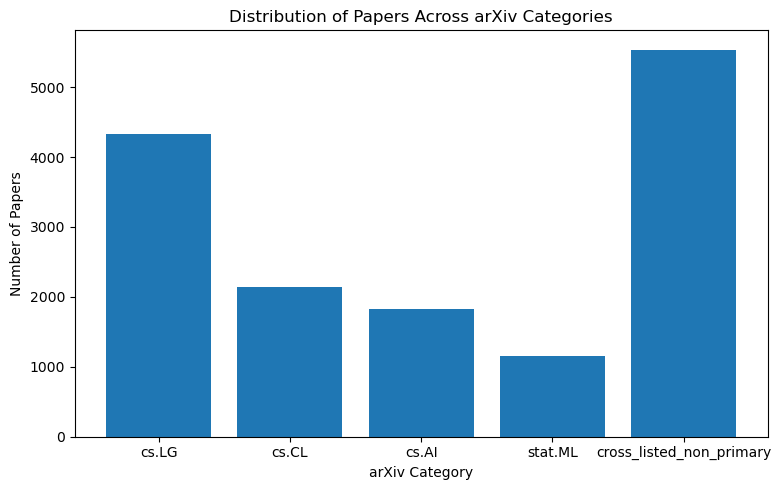

In [11]:
categories = [p["primary_category"] for p in papers]

# Category distribution
print("Category distribution:")
category_counts = dataset_metadata.get("category_counts", {})
category_counts[OTHER_CATEGORY_LABEL] = dataset_metadata.get("corpus_size") - sum(category_counts.values())
print(category_counts)
plt.figure(figsize=(8, 5))
plt.bar(category_counts.keys(), category_counts.values())
plt.xlabel("arXiv Category")
plt.ylabel("Number of Papers")
plt.title("Distribution of Papers Across arXiv Categories")
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, "category_distribution.png"), dpi=300)
plt.show()
plt.close()

### 4.2 Abstract Length Distribution

**Justification:** Abstract length influences text representation quality and can bias embedding-based retrieval. This helps validate preprocessing and model input assumptions.

Abstract length distribution:


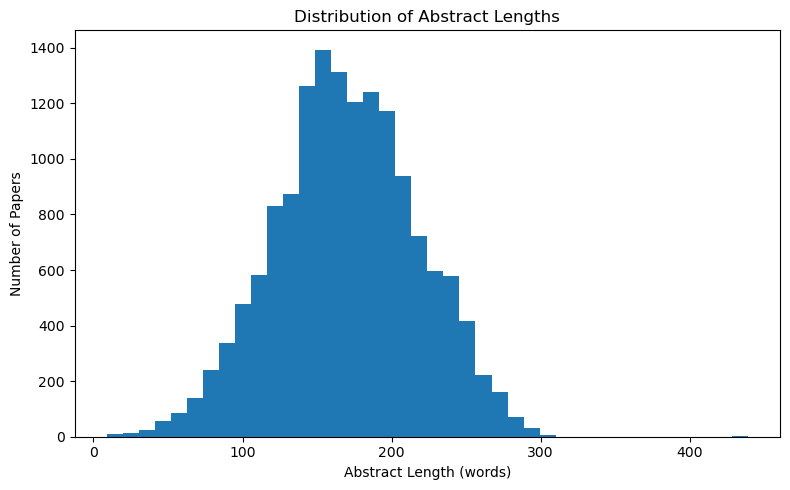

In [12]:
abstract_lengths = [len(p["abstract"].split()) for p in papers]

# Abstract length distribution
print("Abstract length distribution:")
plt.figure(figsize=(8, 5))
plt.hist(abstract_lengths, bins=40)
plt.xlabel("Abstract Length (words)")
plt.ylabel("Number of Papers")
plt.title("Distribution of Abstract Lengths")
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, "abstract_length_distribution.png"), dpi=300)
plt.show()
plt.close()

### 4.3 Corpus Summary Statistics

**Justification:** High-level corpus statistics provide a compact quality check and establish reproducible baseline characteristics for later experiments.

In [13]:

# Save corpus summary table
corpus_summary = pd.DataFrame([
    {"Statistic": "Corpus size", "Value": len(papers)},
    {"Statistic": "Average abstract length", "Value": round(np.mean(abstract_lengths), 2)},
    {"Statistic": "Median abstract length", "Value": round(np.median(abstract_lengths), 2)},
    {"Statistic": "Vocabulary proxy (unique categories)", "Value": len(set(categories))}
])
print("Corpus summary:")
print(corpus_summary)
save_dataframe(corpus_summary, os.path.join(TABLES_DIR, "corpus_summary.csv"))

Corpus summary:
                              Statistic     Value
0                           Corpus size  15000.00
1               Average abstract length    169.89
2                Median abstract length    169.00
3  Vocabulary proxy (unique categories)    119.00


### 4.4 Data Quality Audit

**Justification:** Missing and invalid values directly affect matching quality, retrieval performance, and reproducibility. Auditing key fields quantifies data reliability before modeling.

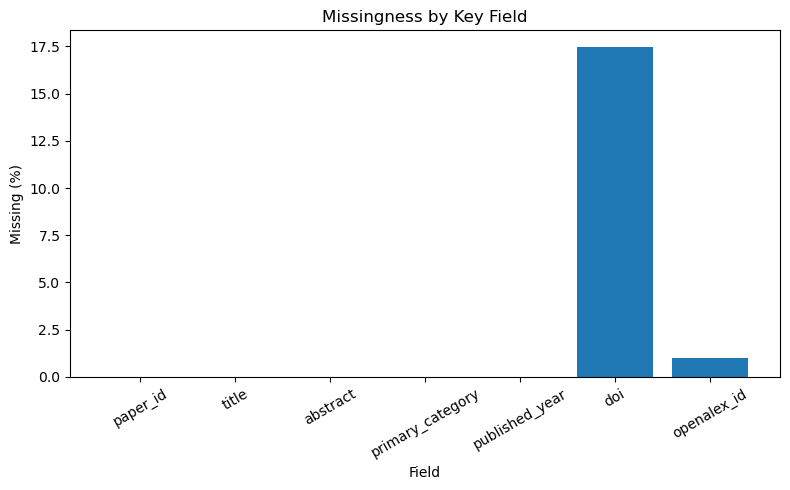

In [14]:
OPENALEX_META_PATH = os.path.join(DATA_DIR, "openalex_enrichment_metadata.json")

papers_df = pd.DataFrame(papers)
queries_df = pd.DataFrame(queries)
qrels_df = pd.DataFrame(qrels)

required_fields = ["paper_id", "title", "abstract", "primary_category", "published_year", "doi", "openalex_id"]
quality_rows = []

for field in required_fields:
    if field not in papers_df.columns:
        missing_count = len(papers_df)
    else:
        series = papers_df[field]
        if field in ["paper_id", "title", "abstract", "primary_category", "doi", "openalex_id"]:
            missing_count = int(series.isna().sum() + series.astype(str).str.strip().eq("").sum())
        else:
            missing_count = int(series.isna().sum())

    quality_rows.append({
        "field": field,
        "missing_count": missing_count,
        "missing_percent": round((missing_count / len(papers_df)) * 100, 2) if len(papers_df) else 0,
    })

quality_df = pd.DataFrame(quality_rows)

eligible_mask = (
    papers_df.get("paper_id", pd.Series([""] * len(papers_df))).astype(str).str.strip().ne("")
    & papers_df.get("title", pd.Series([""] * len(papers_df))).astype(str).str.strip().ne("")
    & papers_df.get("abstract", pd.Series([""] * len(papers_df))).astype(str).str.strip().ne("")
)

cleaning_summary_df = pd.DataFrame([
    {"metric": "raw_records", "value": int(len(papers_df))},
    {"metric": "records_after_cleaning_rules", "value": int(eligible_mask.sum())},
    {"metric": "dropped_by_cleaning_rules", "value": int((~eligible_mask).sum())},
    {
        "metric": "drop_rate_percent",
        "value": round((((~eligible_mask).sum() / len(papers_df)) * 100), 2) if len(papers_df) else 0,
    },
])

save_dataframe(quality_df, os.path.join(TABLES_DIR, "data_quality_summary.csv"))
save_dataframe(cleaning_summary_df, os.path.join(TABLES_DIR, "cleaning_summary.csv"))

plt.figure(figsize=(8, 5))
plt.bar(quality_df["field"], quality_df["missing_percent"])
plt.xlabel("Field")
plt.ylabel("Missing (%)")
plt.title("Missingness by Key Field")
plt.xticks(rotation=30)
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, "missingness_by_field.png"), dpi=300)
plt.show()
plt.close()

### 4.5 OpenAlex Enrichment Quality

**Justification:** Recommendation quality depends on enrichment coverage. This analysis evaluates match success, failure modes, and enrichment confidence.

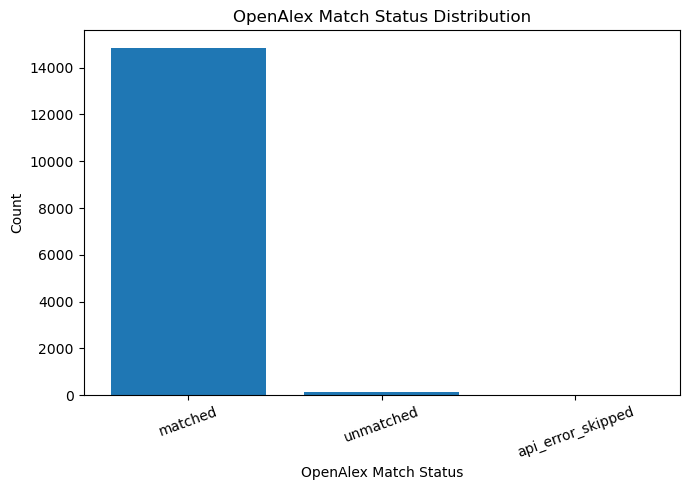

In [15]:
status_series = papers_df.get("openalex_match_status", pd.Series(["missing"] * len(papers_df)))
status_counts = status_series.fillna("missing").value_counts().sort_values(ascending=False)
status_df = pd.DataFrame({"openalex_match_status": status_counts.index, "count": status_counts.values})
save_dataframe(status_df, os.path.join(TABLES_DIR, "openalex_match_status_counts.csv"))

if os.path.exists(OPENALEX_META_PATH):
    openalex_meta = load_json(OPENALEX_META_PATH)
    enrichment_quality_df = pd.DataFrame([
        {"metric": "matched_by_doi", "value": openalex_meta.get("matched_by_doi", 0)},
        {"metric": "matched_by_title", "value": openalex_meta.get("matched_by_title", 0)},
        {"metric": "unmatched", "value": openalex_meta.get("unmatched", 0)},
        {"metric": "api_errors_skipped", "value": openalex_meta.get("api_errors_skipped", 0)},
        {"metric": "match_rate", "value": openalex_meta.get("match_rate", 0)},
    ])
    save_dataframe(enrichment_quality_df, os.path.join(TABLES_DIR, "openalex_enrichment_quality.csv"))

plt.figure(figsize=(7, 5))
plt.bar(status_df["openalex_match_status"], status_df["count"])
plt.xlabel("OpenAlex Match Status")
plt.ylabel("Count")
plt.title("OpenAlex Match Status Distribution")
plt.xticks(rotation=20)
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, "openalex_match_status_distribution.png"), dpi=300)
plt.show()
plt.close()

### 4.6 Citation Structure Analysis

**Justification:** Citation-based signals support relevance modeling and query generation. Understanding citation distributions helps justify their use and limitations.

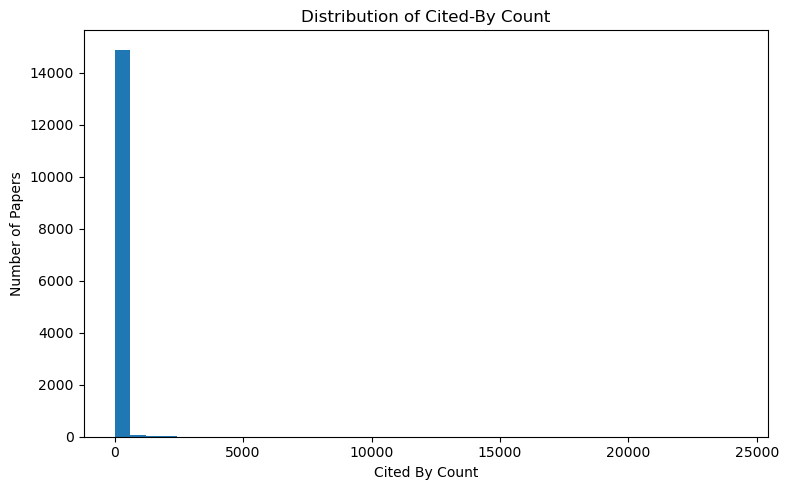

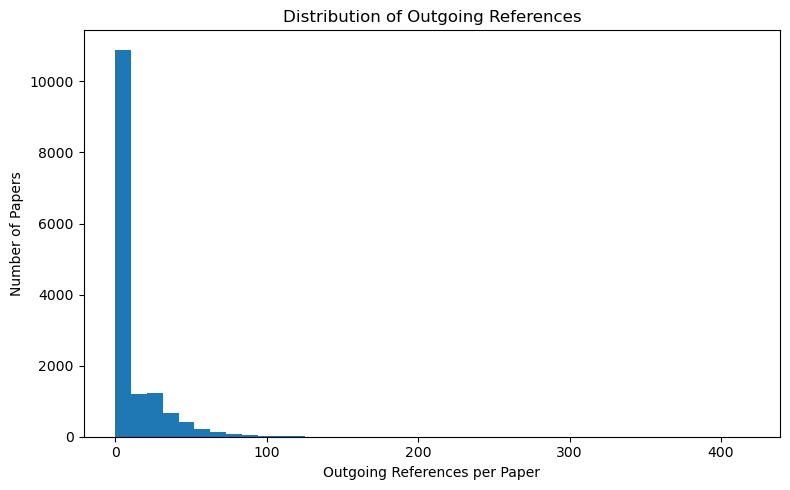

In [16]:
cited_by = pd.to_numeric(papers_df.get("cited_by_count", pd.Series([0] * len(papers_df))), errors="coerce").fillna(0)
outgoing_refs = papers_df.get("referenced_works", pd.Series([[]] * len(papers_df))).apply(
    lambda x: len(x) if isinstance(x, list) else 0
)

citation_summary_df = pd.DataFrame([
    {"metric": "avg_cited_by_count", "value": round(float(cited_by.mean()), 2)},
    {"metric": "median_cited_by_count", "value": round(float(cited_by.median()), 2)},
    {"metric": "p90_cited_by_count", "value": round(float(np.percentile(cited_by, 90)), 2) if len(cited_by) else 0},
    {"metric": "avg_outgoing_references", "value": round(float(outgoing_refs.mean()), 2)},
    {"metric": "median_outgoing_references", "value": round(float(outgoing_refs.median()), 2)},
])
save_dataframe(citation_summary_df, os.path.join(TABLES_DIR, "citation_summary.csv"))

plt.figure(figsize=(8, 5))
plt.hist(cited_by, bins=40)
plt.xlabel("Cited By Count")
plt.ylabel("Number of Papers")
plt.title("Distribution of Cited-By Count")
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, "cited_by_count_distribution.png"), dpi=300)
plt.show()
plt.close()

plt.figure(figsize=(8, 5))
plt.hist(outgoing_refs, bins=40)
plt.xlabel("Outgoing References per Paper")
plt.ylabel("Number of Papers")
plt.title("Distribution of Outgoing References")
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, "outgoing_references_distribution.png"), dpi=300)
plt.show()
plt.close()

### 4.7 Query and Qrels Diagnostics

**Justification:** Retrieval evaluation quality depends on query relevance density. This section checks whether the benchmark is informative and not overly sparse.

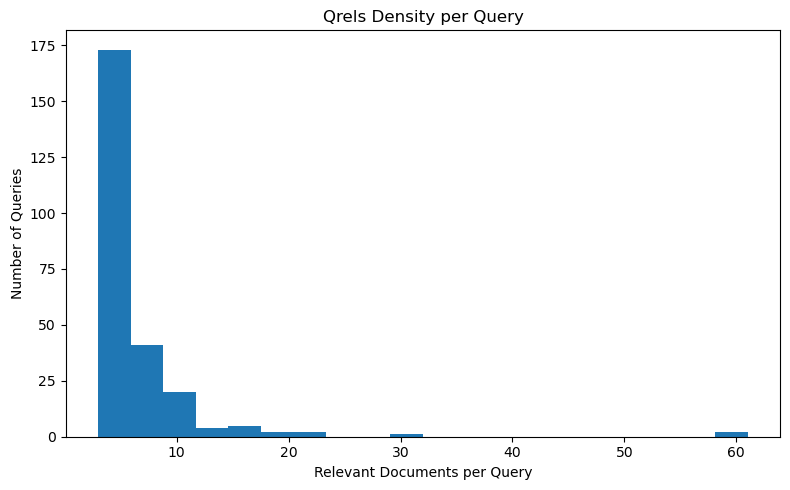

In [17]:
qrels_per_query = qrels_df.groupby("query_id")["doc_id"].nunique().sort_values(ascending=False)
qrels_summary_df = pd.DataFrame([
    {"metric": "num_queries", "value": int(queries_df["query_id"].nunique() if "query_id" in queries_df else 0)},
    {"metric": "num_qrels_pairs", "value": int(len(qrels_df))},
    {"metric": "avg_relevant_docs_per_query", "value": round(float(qrels_per_query.mean()), 2) if len(qrels_per_query) else 0},
    {"metric": "median_relevant_docs_per_query", "value": round(float(qrels_per_query.median()), 2) if len(qrels_per_query) else 0},
    {"metric": "queries_with_<=3_relevant_docs", "value": int((qrels_per_query <= 3).sum()) if len(qrels_per_query) else 0},
])
save_dataframe(qrels_summary_df, os.path.join(TABLES_DIR, "qrels_summary.csv"))

plt.figure(figsize=(8, 5))
plt.hist(qrels_per_query.values, bins=20)
plt.xlabel("Relevant Documents per Query")
plt.ylabel("Number of Queries")
plt.title("Qrels Density per Query")
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, "qrels_per_query_distribution.png"), dpi=300)
plt.show()
plt.close()

### 4.8 Class Imbalance and Duplicate Checks

**Justification:** Imbalance and duplicates can bias evaluation and inflate apparent performance. These checks support critical discussion of dataset threats to validity.

In [18]:
cat_counts = pd.Series(dataset_metadata.get("category_counts", {}), dtype="float64")
imbalance_ratio = round(float(cat_counts.max() / cat_counts.min()), 3) if len(cat_counts) and cat_counts.min() > 0 else np.nan

norm_titles = papers_df.get("title", pd.Series([""] * len(papers_df))).fillna("").astype(str).str.lower()
norm_titles = norm_titles.str.replace(r"\s+", " ", regex=True).str.strip()

doi_series = papers_df.get("doi", pd.Series([""] * len(papers_df))).fillna("").astype(str).str.lower().str.strip()
doi_series = doi_series.str.replace("https://doi.org/", "", regex=False)
doi_series = doi_series.str.replace("http://doi.org/", "", regex=False)
doi_series = doi_series.str.replace("doi.org/", "", regex=False)
non_empty_doi = doi_series[doi_series.ne("")]

imbalance_duplicate_df = pd.DataFrame([
    {"metric": "category_imbalance_ratio_max_over_min", "value": imbalance_ratio},
    {"metric": "duplicate_titles_exact_count", "value": int(norm_titles.duplicated().sum())},
    {"metric": "duplicate_doi_exact_count", "value": int(non_empty_doi.duplicated().sum())},
])
print("Imbalance and duplicates summary:")
print(imbalance_duplicate_df)
save_dataframe(imbalance_duplicate_df, os.path.join(TABLES_DIR, "imbalance_and_duplicates_summary.csv"))

print("Section 4 exploration outputs saved to outputs/figures and outputs/tables.")

Imbalance and duplicates summary:
                                  metric  value
0  category_imbalance_ratio_max_over_min  4.791
1           duplicate_titles_exact_count  4.000
2              duplicate_doi_exact_count  4.000
Section 4 exploration outputs saved to outputs/figures and outputs/tables.


## 5. Data Cleaning

In [19]:
cleaned_papers = []

for p in papers:
    title = normalise_whitespace(p.get("title", ""))
    abstract = normalise_whitespace(p.get("abstract", ""))
    primary_category = p.get("primary_category", "")
    paper_id = p.get("paper_id", "")

    if not paper_id or not title or not abstract:
        continue

    cleaned_papers.append({
        **p,
        "title": title,
        "abstract": abstract,
        "primary_category": primary_category,
        "text": f"{title} {abstract}".strip()
    })

## 6. Preprocessing

In [20]:
# Normalize categories for experiments:
# keep target categories as-is, map non-primary target-cross-listed papers to the fallback label
for p in cleaned_papers:
    p["experiment_category"] = to_experiment_category(p.get("primary_category", ""))

In [21]:
print("Building lookup structures...")
paper_map = {p["paper_id"]: p for p in cleaned_papers}
query_map = {q["query_id"]: q for q in queries}

qrels_map = defaultdict(list)
for r in qrels:
    qrels_map[r["query_id"]].append(r["doc_id"])

Building lookup structures...


In [22]:
print("Building corpus index...")


paper_ids = [p["paper_id"] for p in cleaned_papers]
texts = [p["text"] for p in cleaned_papers]

index = CorpusIndex(paper_ids=paper_ids, texts=texts)


Building corpus index...


In [23]:
# TF-IDF Indexing
def fit_tfidf(
    texts: List[str],
    lowercase: bool = True,
    stop_words: str = "english",
    ngram_range: Tuple[int, int] = (1, 1),
    norm: str = "l2",
) -> Tuple[TfidfVectorizer, np.ndarray, float]:
    start = time.perf_counter()

    vectorizer = TfidfVectorizer(
        lowercase=lowercase,
        stop_words=stop_words,
        ngram_range=ngram_range,
        norm=norm,
    )
    matrix = vectorizer.fit_transform(texts)

    elapsed = time.perf_counter() - start
    return vectorizer, matrix, elapsed

print("Fitting TF-IDF...")
vectorizer, matrix, tfidf_build_time = fit_tfidf(index.texts)
index.tfidf_vectorizer = vectorizer
index.tfidf_matrix = matrix
print(f"TF-IDF indexing completed in {tfidf_build_time:.2f} seconds")

Fitting TF-IDF...
TF-IDF indexing completed in 0.83 seconds


In [24]:
# Dense Embeddings
def build_dense_embeddings(
    texts: List[str],
    model_name: str = SBERT_MODEL_NAME,
    batch_size: int = 64,
    show_progress_bar: bool = True,
    normalize_embeddings: bool = True,
) -> Tuple[SentenceTransformer, np.ndarray, float]:
    start = time.perf_counter()

    model = SentenceTransformer(model_name)
    dense_matrix = model.encode(
        texts,
        batch_size=batch_size,
        show_progress_bar=show_progress_bar,
        convert_to_numpy=True,
        normalize_embeddings=normalize_embeddings,
    )

    elapsed = time.perf_counter() - start
    return model, dense_matrix, elapsed

print("Encoding SBERT embeddings...")
dense_model, dense_matrix, dense_build_time = build_dense_embeddings(index.texts, model_name=SBERT_MODEL_NAME)
index.dense_model = dense_model
index.dense_matrix = dense_matrix
print(f"SBERT embedding completed in {dense_build_time:.2f} seconds")

Encoding SBERT embeddings...


Batches: 100%|██████████| 235/235 [00:40<00:00,  5.83it/s]


SBERT embedding completed in 42.94 seconds


## 7. Evaluation

### 7.1 TF-IDF Evaluation

In [25]:
print("Evaluating TF-IDF...")
tfidf_results = evaluate_system(
    "TF-IDF",
    queries,
    qrels_map,
    index,
    lambda qt, idx: rank_tfidf(qt, idx, top_n=1000)
)
print("TF-IDF evaluation results:")
print(tfidf_results)

Evaluating TF-IDF...
TF-IDF evaluation results:
     system query_id  latency_seconds  latency_p90_seconds       mrr  \
0    TF-IDF     Q001         0.007897             0.012561  0.500000   
1    TF-IDF     Q002         0.006886             0.006944  0.500000   
2    TF-IDF     Q003         0.007507             0.008371  0.050000   
3    TF-IDF     Q004         0.006869             0.010434  0.033333   
4    TF-IDF     Q005         0.006962             0.010401  0.500000   
..      ...      ...              ...                  ...       ...   
245  TF-IDF     Q246         0.006681             0.006739  0.500000   
246  TF-IDF     Q247         0.006992             0.007317  0.142857   
247  TF-IDF     Q248         0.006664             0.007111  0.500000   
248  TF-IDF     Q249         0.007037             0.007175  0.100000   
249  TF-IDF     Q250         0.006923             0.007151  0.250000   

     precision@5  recall@5    ndcg@5  precision@10  recall@10   ndcg@10  \
0           

### 7.1.1 TF-IDF Tuning (after TF-IDF evaluation)

This tuning step selects the best TF-IDF configuration first, then updates the shared index before downstream fusion models.

In [26]:
# TF-IDF tuning settings
TUNING_QUERY_LIMIT = 80  # set to None for all queries
TUNING_TFIDF_NGRAMS = [(1, 1), (1, 2)]

# Keep these as explicit variables so Hybrid/Two-Stage use tuned components
BEST_HYBRID_ALPHA = HYBRID_ALPHA
BEST_TWO_STAGE_CANDIDATE_SIZE = TWO_STAGE_CANDIDATE_SIZE


tfidf_tuning_queries = queries if TUNING_QUERY_LIMIT is None else queries[:TUNING_QUERY_LIMIT]
print(f"Running TF-IDF tuning on {len(tfidf_tuning_queries)} queries...")

tfidf_tuning_rows = []
for ngram in TUNING_TFIDF_NGRAMS:
    vec, mat, _ = fit_tfidf(index.texts, ngram_range=ngram)

    tuned_index = CorpusIndex(
        paper_ids=index.paper_ids,
        texts=index.texts,
        tfidf_vectorizer=vec,
        tfidf_matrix=mat,
        dense_model=index.dense_model,
        dense_matrix=index.dense_matrix,
    )

    run_df = evaluate_system(
        "TF-IDF-Tuned",
        tfidf_tuning_queries,
        qrels_map,
        tuned_index,
        lambda qt, idx: rank_tfidf(qt, idx, top_n=1000),
    )

    tfidf_tuning_rows.append({
        "tfidf_ngram_range": str(ngram),
        "query_count": len(tfidf_tuning_queries),
        "latency_seconds": float(run_df["latency_seconds"].mean()),
        "mrr": float(run_df["mrr"].mean()),
        "precision@5": float(run_df["precision@5"].mean()),
        "recall@5": float(run_df["recall@5"].mean()),
        "ndcg@5": float(run_df["ndcg@5"].mean()),
        "precision@10": float(run_df["precision@10"].mean()),
        "recall@10": float(run_df["recall@10"].mean()),
        "ndcg@10": float(run_df["ndcg@10"].mean()),
        "precision@20": float(run_df["precision@20"].mean()),
        "recall@20": float(run_df["recall@20"].mean()),
        "ndcg@20": float(run_df["ndcg@20"].mean()),
    })

tfidf_tuning_df = pd.DataFrame(tfidf_tuning_rows).sort_values(["ndcg@10", "latency_seconds"], ascending=[False, True])
BEST_TFIDF_NGRAM = eval(tfidf_tuning_df.iloc[0]["tfidf_ngram_range"])

# Refit index with best TF-IDF setting
best_vec, best_mat, _ = fit_tfidf(index.texts, ngram_range=BEST_TFIDF_NGRAM)
index.tfidf_vectorizer = best_vec
index.tfidf_matrix = best_mat

save_dataframe(tfidf_tuning_df, os.path.join(METRICS_DIR, "tfidf_tuning_results.csv"))
save_json(
    {
        "best_tfidf_ngram_range": str(BEST_TFIDF_NGRAM),
        "selection_rule": "best ndcg@10, then lowest latency",
        "query_count": int(len(tfidf_tuning_queries)),
        "best_row": tfidf_tuning_df.iloc[0].to_dict(),
    },
    os.path.join(METRICS_DIR, "best_tfidf_config.json"),
)

print("TF-IDF tuning results:")
print(tfidf_tuning_df)
print(f"Selected BEST_TFIDF_NGRAM = {BEST_TFIDF_NGRAM}")

Running TF-IDF tuning on 80 queries...
TF-IDF tuning results:
  tfidf_ngram_range  query_count  latency_seconds       mrr  precision@5  \
1            (1, 2)           80         0.023380  0.224277       0.1275   
0            (1, 1)           80         0.007147  0.227247       0.1300   

   recall@5    ndcg@5  precision@10  recall@10  ndcg@10  precision@20  \
1  0.154061  0.136014       0.11000   0.256368  0.18099      0.070000   
0  0.154860  0.136857       0.10875   0.251760  0.17806      0.066875   

   recall@20   ndcg@20  
1   0.316427  0.204105  
0   0.303502  0.198018  
Selected BEST_TFIDF_NGRAM = (1, 2)


### 7.2 SBERT Evaluation

In [27]:
print("Evaluating SBERT...")
sbert_results = evaluate_system(
    "SBERT",
    queries,
    qrels_map,
    index,
    lambda qt, idx: rank_dense(qt, idx, top_n=1000)
)
print("SBERT evaluation results:")
print(sbert_results)


Evaluating SBERT...
SBERT evaluation results:
    system query_id  latency_seconds  latency_p90_seconds       mrr  \
0    SBERT     Q001         0.017063             0.017541  0.250000   
1    SBERT     Q002         0.014650             0.015509  0.500000   
2    SBERT     Q003         0.013901             0.014104  0.125000   
3    SBERT     Q004         0.013087             0.014555  0.015385   
4    SBERT     Q005         0.014129             0.014661  0.333333   
..     ...      ...              ...                  ...       ...   
245  SBERT     Q246         0.011579             0.011703  0.333333   
246  SBERT     Q247         0.011878             0.013495  0.500000   
247  SBERT     Q248         0.013466             0.013602  0.333333   
248  SBERT     Q249         0.011886             0.012604  0.500000   
249  SBERT     Q250         0.011757             0.014336  0.090909   

     precision@5  recall@5    ndcg@5  precision@10  recall@10   ndcg@10  \
0            0.4  0.500000

### 7.2.1 SBERT Model Tuning (after SBERT evaluation)

This tuning step selects the best dense embedding model, then updates the shared index so Hybrid and Two-Stage use the tuned SBERT component together with the tuned TF-IDF index.

In [28]:
TUNING_DENSE_MODELS = [
    SBERT_MODEL_NAME,
    "sentence-transformers/multi-qa-MiniLM-L6-cos-v1",
]

sbert_tuning_queries = queries if TUNING_QUERY_LIMIT is None else queries[:TUNING_QUERY_LIMIT]
print(f"Running SBERT model tuning on {len(sbert_tuning_queries)} queries...")

sbert_tuning_rows = []
best_dense_model_obj = None
best_dense_matrix = None

for model_name in TUNING_DENSE_MODELS:
    print(f"\nEncoding dense embeddings for: {model_name}")
    model, dense_matrix, encode_elapsed = build_dense_embeddings(
        index.texts,
        model_name=model_name,
        batch_size=64,
        show_progress_bar=True,
        normalize_embeddings=True,
    )

    tuned_index = CorpusIndex(
        paper_ids=index.paper_ids,
        texts=index.texts,
        tfidf_vectorizer=index.tfidf_vectorizer,
        tfidf_matrix=index.tfidf_matrix,
        dense_model=model,
        dense_matrix=dense_matrix,
    )

    run_df = evaluate_system(
        "SBERT-Tuned",
        sbert_tuning_queries,
        qrels_map,
        tuned_index,
        lambda qt, idx: rank_dense(qt, idx, top_n=1000),
    )

    row = {
        "dense_model": model_name,
        "query_count": len(sbert_tuning_queries),
        "dense_build_seconds": encode_elapsed,
        "latency_seconds": float(run_df["latency_seconds"].mean()),
        "mrr": float(run_df["mrr"].mean()),
        "precision@5": float(run_df["precision@5"].mean()),
        "recall@5": float(run_df["recall@5"].mean()),
        "ndcg@5": float(run_df["ndcg@5"].mean()),
        "precision@10": float(run_df["precision@10"].mean()),
        "recall@10": float(run_df["recall@10"].mean()),
        "ndcg@10": float(run_df["ndcg@10"].mean()),
        "precision@20": float(run_df["precision@20"].mean()),
        "recall@20": float(run_df["recall@20"].mean()),
        "ndcg@20": float(run_df["ndcg@20"].mean()),
    }
    sbert_tuning_rows.append(row)

sbert_tuning_df = pd.DataFrame(sbert_tuning_rows).sort_values(["ndcg@10", "latency_seconds"], ascending=[False, True])
BEST_SBERT_MODEL = sbert_tuning_df.iloc[0]["dense_model"]

# Rebuild and persist best dense model into shared index
best_dense_model_obj, best_dense_matrix, _ = build_dense_embeddings(
    index.texts,
    model_name=BEST_SBERT_MODEL,
    batch_size=64,
    show_progress_bar=True,
    normalize_embeddings=True,
)
index.dense_model = best_dense_model_obj
index.dense_matrix = best_dense_matrix

save_dataframe(sbert_tuning_df, os.path.join(METRICS_DIR, "sbert_model_tuning_results.csv"))
save_json(
    {
        "best_sbert_model": BEST_SBERT_MODEL,
        "selection_rule": "best ndcg@10, then lowest latency",
        "query_count": int(len(sbert_tuning_queries)),
        "best_row": sbert_tuning_df.iloc[0].to_dict(),
    },
    os.path.join(METRICS_DIR, "best_sbert_model_config.json"),
)

print("SBERT model tuning results:")
print(sbert_tuning_df)
print(f"Selected BEST_SBERT_MODEL = {BEST_SBERT_MODEL}")

Running SBERT model tuning on 80 queries...

Encoding dense embeddings for: all-MiniLM-L6-v2


Batches: 100%|██████████| 235/235 [00:38<00:00,  6.06it/s]



Encoding dense embeddings for: sentence-transformers/multi-qa-MiniLM-L6-cos-v1


Batches: 100%|██████████| 235/235 [00:39<00:00,  6.02it/s]


SBERT model tuning results:
                                       dense_model  query_count  \
0                                 all-MiniLM-L6-v2           80   
1  sentence-transformers/multi-qa-MiniLM-L6-cos-v1           80   

   dense_build_seconds  latency_seconds       mrr  precision@5  recall@5  \
0            40.782349         0.012867  0.247267       0.1925  0.220622   
1           209.948647         0.013603  0.199311       0.1200  0.138913   

     ndcg@5  precision@10  recall@10   ndcg@10  precision@20  recall@20  \
0  0.187902       0.14625   0.322158  0.227127        0.0925   0.394375   
1  0.122061       0.09250   0.202541  0.148131        0.0700   0.297617   

    ndcg@20  
0  0.255884  
1  0.185209  
Selected BEST_SBERT_MODEL = all-MiniLM-L6-v2


### 7.3 Hybrid Evaluation (using tuned TF-IDF + tuned SBERT)

In [29]:
print(
    f"Evaluating Hybrid with tuned components (tfidf_ngram={BEST_TFIDF_NGRAM}, "
    f"sbert_model={BEST_SBERT_MODEL}, alpha={BEST_HYBRID_ALPHA})..."
)
hybrid_results = evaluate_system(
    "Hybrid",
    queries,
    qrels_map,
    index,
    lambda qt, idx: rank_hybrid(qt, idx, alpha=BEST_HYBRID_ALPHA, top_n=1000)
)
print("Hybrid evaluation results:")
print(hybrid_results)


Evaluating Hybrid with tuned components (tfidf_ngram=(1, 2), sbert_model=all-MiniLM-L6-v2, alpha=0.5)...
Hybrid evaluation results:
     system query_id  latency_seconds  latency_p90_seconds       mrr  \
0    Hybrid     Q001         0.081841             0.084623  0.333333   
1    Hybrid     Q002         0.066904             0.075740  0.500000   
2    Hybrid     Q003         0.062127             0.068124  0.166667   
3    Hybrid     Q004         0.056391             0.065323  0.016129   
4    Hybrid     Q005         0.060905             0.062335  0.333333   
..      ...      ...              ...                  ...       ...   
245  Hybrid     Q246         0.060410             0.063198  0.500000   
246  Hybrid     Q247         0.058263             0.063959  0.333333   
247  Hybrid     Q248         0.061231             0.064015  0.333333   
248  Hybrid     Q249         0.059707             0.062356  0.500000   
249  Hybrid     Q250         0.059987             0.060515  0.083333   

   

### 7.3.1 Fusion Parameter Tuning (after Hybrid, before Two-Stage)

This stage tunes fusion-specific parameters on the already tuned TF-IDF and SBERT components:
- `BEST_HYBRID_ALPHA`
- `BEST_TWO_STAGE_CANDIDATE_SIZE`

Selection rule: best `nDCG@10`, then lower latency.

In [30]:
# Fusion tuning settings (can be adjusted)
TUNING_HYBRID_ALPHAS = [0.3, 0.5, 0.7]
TUNING_TWO_STAGE_CANDIDATES = [50, 100, 200]

fusion_tuning_queries = queries if TUNING_QUERY_LIMIT is None else queries[:TUNING_QUERY_LIMIT]
print(f"Running fusion tuning on {len(fusion_tuning_queries)} queries...")

# --- Hybrid alpha tuning ---
hybrid_tuning_rows = []
for alpha in TUNING_HYBRID_ALPHAS:
    run_df = evaluate_system(
        "Hybrid-Alpha-Tuning",
        fusion_tuning_queries,
        qrels_map,
        index,
        lambda qt, idx: rank_hybrid(qt, idx, alpha=alpha, top_n=1000),
    )

    hybrid_tuning_rows.append({
        "hybrid_alpha": alpha,
        "query_count": len(fusion_tuning_queries),
        "latency_seconds": float(run_df["latency_seconds"].mean()),
        "mrr": float(run_df["mrr"].mean()),
        "precision@5": float(run_df["precision@5"].mean()),
        "recall@5": float(run_df["recall@5"].mean()),
        "ndcg@5": float(run_df["ndcg@5"].mean()),
        "precision@10": float(run_df["precision@10"].mean()),
        "recall@10": float(run_df["recall@10"].mean()),
        "ndcg@10": float(run_df["ndcg@10"].mean()),
        "precision@20": float(run_df["precision@20"].mean()),
        "recall@20": float(run_df["recall@20"].mean()),
        "ndcg@20": float(run_df["ndcg@20"].mean()),
    })

hybrid_alpha_tuning_df = pd.DataFrame(hybrid_tuning_rows).sort_values(["ndcg@10", "latency_seconds"], ascending=[False, True])
BEST_HYBRID_ALPHA = float(hybrid_alpha_tuning_df.iloc[0]["hybrid_alpha"])

# Recompute hybrid on full query set with tuned alpha so downstream summaries use tuned result
hybrid_results = evaluate_system(
    "Hybrid",
    queries,
    qrels_map,
    index,
    lambda qt, idx: rank_hybrid(qt, idx, alpha=BEST_HYBRID_ALPHA, top_n=1000),
)

save_dataframe(hybrid_alpha_tuning_df, os.path.join(METRICS_DIR, "hybrid_alpha_tuning_results.csv"))


print("Hybrid alpha tuning results:")
print(hybrid_alpha_tuning_df)
print(f"Selected BEST_HYBRID_ALPHA = {BEST_HYBRID_ALPHA}")
print("Saved fusion tuning outputs to outputs/metrics/")

Running fusion tuning on 80 queries...
Hybrid alpha tuning results:
   hybrid_alpha  query_count  latency_seconds       mrr  precision@5  \
1           0.5           80         0.059930  0.264423       0.2075   
2           0.7           80         0.059257  0.264268       0.1975   
0           0.3           80         0.059341  0.259222       0.2100   

   recall@5    ndcg@5  precision@10  recall@10   ndcg@10  precision@20  \
1  0.243471  0.203570       0.15250   0.340672  0.242816      0.096250   
2  0.235545  0.196996       0.15125   0.340846  0.240679      0.095000   
0  0.245319  0.204177       0.15250   0.338728  0.239783      0.096875   

   recall@20   ndcg@20  
1   0.411007  0.271421  
2   0.417891  0.270718  
0   0.409687  0.268142  
Selected BEST_HYBRID_ALPHA = 0.5
Saved fusion tuning outputs to outputs/metrics/


### 7.4 Two-Stage Evaluation (using tuned TF-IDF + tuned SBERT)

In [31]:

# --- Two-stage candidate-size tuning ---
two_stage_tuning_rows = []
for candidate_size in TUNING_TWO_STAGE_CANDIDATES:
    run_df = evaluate_system(
        "Two-Stage-Candidate-Tuning",
        fusion_tuning_queries,
        qrels_map,
        index,
        lambda qt, idx: rank_two_stage(qt, idx, candidate_size=candidate_size, top_n=1000),
    )

    two_stage_tuning_rows.append({
        "two_stage_candidate_size": candidate_size,
        "query_count": len(fusion_tuning_queries),
        "latency_seconds": float(run_df["latency_seconds"].mean()),
        "mrr": float(run_df["mrr"].mean()),
        "precision@5": float(run_df["precision@5"].mean()),
        "recall@5": float(run_df["recall@5"].mean()),
        "ndcg@5": float(run_df["ndcg@5"].mean()),
        "precision@10": float(run_df["precision@10"].mean()),
        "recall@10": float(run_df["recall@10"].mean()),
        "ndcg@10": float(run_df["ndcg@10"].mean()),
        "precision@20": float(run_df["precision@20"].mean()),
        "recall@20": float(run_df["recall@20"].mean()),
        "ndcg@20": float(run_df["ndcg@20"].mean()),
    })

two_stage_candidate_tuning_df = pd.DataFrame(two_stage_tuning_rows).sort_values(["ndcg@10", "latency_seconds"], ascending=[False, True])
BEST_TWO_STAGE_CANDIDATE_SIZE = int(two_stage_candidate_tuning_df.iloc[0]["two_stage_candidate_size"])

save_dataframe(two_stage_candidate_tuning_df, os.path.join(METRICS_DIR, "two_stage_candidate_tuning_results.csv"))
save_json(
    {
        "selection_rule": "best ndcg@10, then lowest latency",
        "query_count": int(len(fusion_tuning_queries)),
        "best_hybrid_alpha": BEST_HYBRID_ALPHA,
        "best_two_stage_candidate_size": BEST_TWO_STAGE_CANDIDATE_SIZE,
        "best_hybrid_alpha_row": hybrid_alpha_tuning_df.iloc[0].to_dict(),
        "best_two_stage_candidate_row": two_stage_candidate_tuning_df.iloc[0].to_dict(),
    },
    os.path.join(METRICS_DIR, "best_fusion_config.json"),
)

print("Two-stage candidate tuning results:")
print(two_stage_candidate_tuning_df)
print(f"Selected BEST_TWO_STAGE_CANDIDATE_SIZE = {BEST_TWO_STAGE_CANDIDATE_SIZE}")

Two-stage candidate tuning results:
   two_stage_candidate_size  query_count  latency_seconds       mrr  \
1                       100           80         0.038949  0.250397   
2                       200           80         0.039035  0.250269   
0                        50           80         0.041393  0.243928   

   precision@5  recall@5    ndcg@5  precision@10  recall@10   ndcg@10  \
1       0.2050  0.241212  0.198885       0.14125   0.324901  0.228591   
2       0.2025  0.235205  0.196615       0.14375   0.322887  0.228164   
0       0.1925  0.232263  0.191112       0.13750   0.320230  0.224772   

   precision@20  recall@20   ndcg@20  
1      0.094375   0.417118  0.265050  
2      0.093125   0.402187  0.260163  
0      0.089375   0.399801  0.256839  
Selected BEST_TWO_STAGE_CANDIDATE_SIZE = 100


In [32]:
print(
    f"Evaluating Two-Stage with tuned components (tfidf_ngram={BEST_TFIDF_NGRAM}, "
    f"sbert_model={BEST_SBERT_MODEL}, candidate_size={BEST_TWO_STAGE_CANDIDATE_SIZE})..."
)
two_stage_results = evaluate_system(
    "Two-Stage",
    queries,
    qrels_map,
    index,
    lambda qt, idx: rank_two_stage(qt, idx, candidate_size=BEST_TWO_STAGE_CANDIDATE_SIZE, top_n=1000)
)
print("Two-Stage evaluation results:")
print(two_stage_results)

Evaluating Two-Stage with tuned components (tfidf_ngram=(1, 2), sbert_model=all-MiniLM-L6-v2, candidate_size=100)...
Two-Stage evaluation results:
        system query_id  latency_seconds  latency_p90_seconds       mrr  \
0    Two-Stage     Q001         0.041929             0.045152  0.250000   
1    Two-Stage     Q002         0.039377             0.041540  0.500000   
2    Two-Stage     Q003         0.037839             0.046405  0.166667   
3    Two-Stage     Q004         0.037476             0.042080  0.020000   
4    Two-Stage     Q005         0.041765             0.042881  0.333333   
..         ...      ...              ...                  ...       ...   
245  Two-Stage     Q246         0.040755             0.041324  0.500000   
246  Two-Stage     Q247         0.038401             0.038595  0.500000   
247  Two-Stage     Q248         0.038065             0.038848  0.333333   
248  Two-Stage     Q249         0.037706             0.040313  0.500000   
249  Two-Stage     Q250     

## 8. Results & Analysis

In [33]:
all_results = pd.concat(
    [tfidf_results, sbert_results, hybrid_results, two_stage_results],
    ignore_index=True
)

summary = summarise_results(all_results)

print("Saving evaluation outputs...")
save_dataframe(all_results, os.path.join(METRICS_DIR, "per_query_results.csv"))
save_dataframe(summary, os.path.join(METRICS_DIR, "summary_results.csv"))

Saving evaluation outputs...


### 8.1 Visual Comparison of Retrieval Systems

This visual summary compares system effectiveness metrics and average query latency to support quick model trade-off analysis.

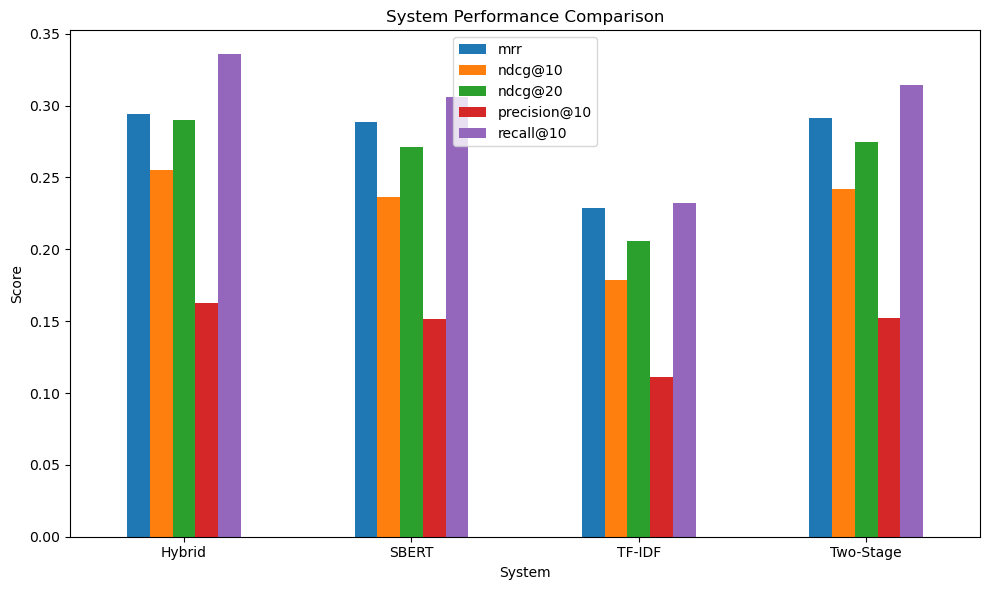

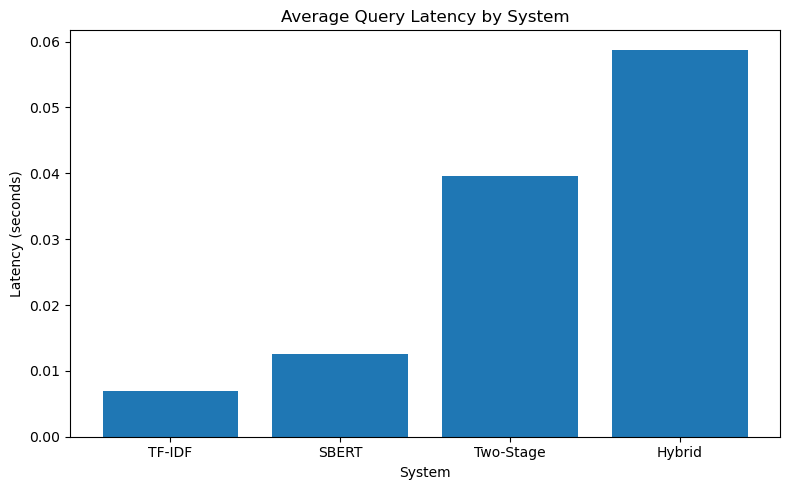

Saved results comparison figures to outputs/figures/


In [34]:
# Rebuild evaluation summary from all_results to avoid stale/overwritten variables.
viz_summary = summarise_results(all_results).copy()

comparison_candidates = ["mrr", "ndcg@10", "ndcg@20", "precision@10", "recall@10"]
comparison_cols = [c for c in comparison_candidates if c in viz_summary.columns]

if not comparison_cols:
    raise ValueError(f"No comparison metrics found in summary columns: {list(viz_summary.columns)}")

comparison_df = viz_summary[["system"] + comparison_cols].set_index("system")

plt.figure(figsize=(10, 6))
comparison_df.plot(kind="bar", ax=plt.gca())
plt.title("System Performance Comparison")
plt.xlabel("System")
plt.ylabel("Score")
plt.xticks(rotation=0)
plt.legend(loc="best")
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, "system_performance_comparison.png"), dpi=300)
plt.show()
plt.close()

if "latency_seconds" not in viz_summary.columns:
    raise ValueError(f"latency_seconds is missing from summary columns: {list(viz_summary.columns)}")

plt.figure(figsize=(8, 5))
latency_df = viz_summary[["system", "latency_seconds"]].sort_values("latency_seconds")
plt.bar(latency_df["system"], latency_df["latency_seconds"])
plt.title("Average Query Latency by System")
plt.xlabel("System")
plt.ylabel("Latency (seconds)")
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, "system_latency_comparison.png"), dpi=300)
plt.show()
plt.close()

print("Saved results comparison figures to outputs/figures/")

In [35]:
efficiency = {
    "tfidf_index_time_seconds": tfidf_build_time,
    "dense_index_time_seconds": dense_build_time,
    "average_tfidf_latency_seconds": float(tfidf_results["latency_seconds"].mean()),
    "average_sbert_latency_seconds": float(sbert_results["latency_seconds"].mean()),
    "average_hybrid_latency_seconds": float(hybrid_results["latency_seconds"].mean()),
    "average_two_stage_latency_seconds": float(two_stage_results["latency_seconds"].mean()),
    "hybrid_alpha": BEST_HYBRID_ALPHA,
    "two_stage_candidate_size": BEST_TWO_STAGE_CANDIDATE_SIZE,
    "sbert_model": BEST_SBERT_MODEL,
    "tfidf_ngram_range": str(BEST_TFIDF_NGRAM)
}
save_json(efficiency, os.path.join(METRICS_DIR, "efficiency_metrics.json"))

### 8.2 Statistical Significance Check

This subsection tests whether observed performance gaps on `nDCG@10` and `MRR` are likely due to real system differences rather than random variation across queries. A paired permutation test is used for p-values, and paired bootstrap is used for 95% confidence intervals of mean deltas.

In [36]:
def paired_permutation_test(x: np.ndarray, y: np.ndarray, n_resamples: int = 5000, seed: int = RANDOM_SEED) -> Tuple[float, float]:
    """Two-sided paired permutation (sign-flip) test on mean difference."""
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)
    d = x - y
    observed = float(d.mean())

    rng = np.random.default_rng(seed)
    signs = rng.choice(np.array([-1.0, 1.0]), size=(n_resamples, d.size))
    perm_means = (signs * d).mean(axis=1)

    p_value = float((np.sum(np.abs(perm_means) >= abs(observed)) + 1) / (n_resamples + 1))
    return observed, p_value


def paired_bootstrap_ci(
    x: np.ndarray,
    y: np.ndarray,
    n_boot: int = 5000,
    ci: float = 95,
    seed: int = RANDOM_SEED,
) -> Tuple[float, float, float]:
    """Bootstrap CI for mean paired difference (x - y)."""
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)
    d = x - y
    n = d.size

    rng = np.random.default_rng(seed)
    idx = rng.integers(0, n, size=(n_boot, n))
    boot_means = d[idx].mean(axis=1)

    alpha = (100 - ci) / 2
    lo, hi = np.percentile(boot_means, [alpha, 100 - alpha])
    return float(d.mean()), float(lo), float(hi)


def cohen_dz_paired(x: np.ndarray, y: np.ndarray) -> float:
    d = np.asarray(x, dtype=float) - np.asarray(y, dtype=float)
    std = float(np.std(d, ddof=1))
    if std == 0:
        return float("nan")
    return float(np.mean(d) / std)


def compare_systems_significance(
    per_query_df: pd.DataFrame,
    system_a: str,
    system_b: str,
    metric: str,
    n_resamples: int = 5000,
) -> Dict:
    a_df = per_query_df[per_query_df["system"] == system_a][["query_id", metric]].rename(columns={metric: "a"})
    b_df = per_query_df[per_query_df["system"] == system_b][["query_id", metric]].rename(columns={metric: "b"})
    merged = a_df.merge(b_df, on="query_id", how="inner").dropna()

    observed, p_value = paired_permutation_test(
        merged["a"].values,
        merged["b"].values,
        n_resamples=n_resamples,
        seed=RANDOM_SEED,
    )
    mean_delta, ci_low, ci_high = paired_bootstrap_ci(
        merged["a"].values,
        merged["b"].values,
        n_boot=n_resamples,
        ci=95,
        seed=RANDOM_SEED,
    )
    effect_size = cohen_dz_paired(merged["a"].values, merged["b"].values)

    return {
        "metric": metric,
        "system_a": system_a,
        "system_b": system_b,
        "n_queries": int(len(merged)),
        "mean_system_a": float(merged["a"].mean()),
        "mean_system_b": float(merged["b"].mean()),
        "mean_delta_a_minus_b": float(mean_delta),
        "p_value_permutation": float(p_value),
        "ci95_low": float(ci_low),
        "ci95_high": float(ci_high),
        "cohen_dz": float(effect_size),
        "is_significant_at_0_05": bool(p_value < 0.05),
    }


if "all_results" in globals() and isinstance(all_results, pd.DataFrame):
    per_query_for_sig = all_results.copy()
else:
    per_query_for_sig = pd.read_csv(os.path.join(METRICS_DIR, "per_query_results.csv"))

pairs_to_compare = [
    ("Hybrid", "Two-Stage"),
    ("Hybrid", "SBERT"),
    ("Hybrid", "TF-IDF"),
    ("Two-Stage", "SBERT"),
    ("Two-Stage", "TF-IDF"),
    ("SBERT", "TF-IDF"),
]
metrics_to_test = ["ndcg@10", "mrr"]

sig_rows = []
for system_a, system_b in pairs_to_compare:
    for metric in metrics_to_test:
        sig_rows.append(
            compare_systems_significance(
                per_query_df=per_query_for_sig,
                system_a=system_a,
                system_b=system_b,
                metric=metric,
                n_resamples=5000,
            )
        )

significance_df = pd.DataFrame(sig_rows).sort_values(["metric", "p_value_permutation"])
print("Paired significance test results:")
print(significance_df)

save_dataframe(significance_df, os.path.join(METRICS_DIR, "significance_tests_ndcg10_mrr.csv"))
print("Saved significance test results to outputs/metrics/significance_tests_ndcg10_mrr.csv")

Paired significance test results:
     metric   system_a   system_b  n_queries  mean_system_a  mean_system_b  \
5       mrr     Hybrid     TF-IDF        250       0.293877       0.229064   
9       mrr  Two-Stage     TF-IDF        250       0.291575       0.229064   
11      mrr      SBERT     TF-IDF        250       0.288733       0.229064   
3       mrr     Hybrid      SBERT        250       0.293877       0.288733   
7       mrr  Two-Stage      SBERT        250       0.291575       0.288733   
1       mrr     Hybrid  Two-Stage        250       0.293877       0.291575   
2   ndcg@10     Hybrid      SBERT        250       0.255004       0.236452   
4   ndcg@10     Hybrid     TF-IDF        250       0.255004       0.178484   
8   ndcg@10  Two-Stage     TF-IDF        250       0.241993       0.178484   
10  ndcg@10      SBERT     TF-IDF        250       0.236452       0.178484   
0   ndcg@10     Hybrid  Two-Stage        250       0.255004       0.241993   
6   ndcg@10  Two-Stage      SB

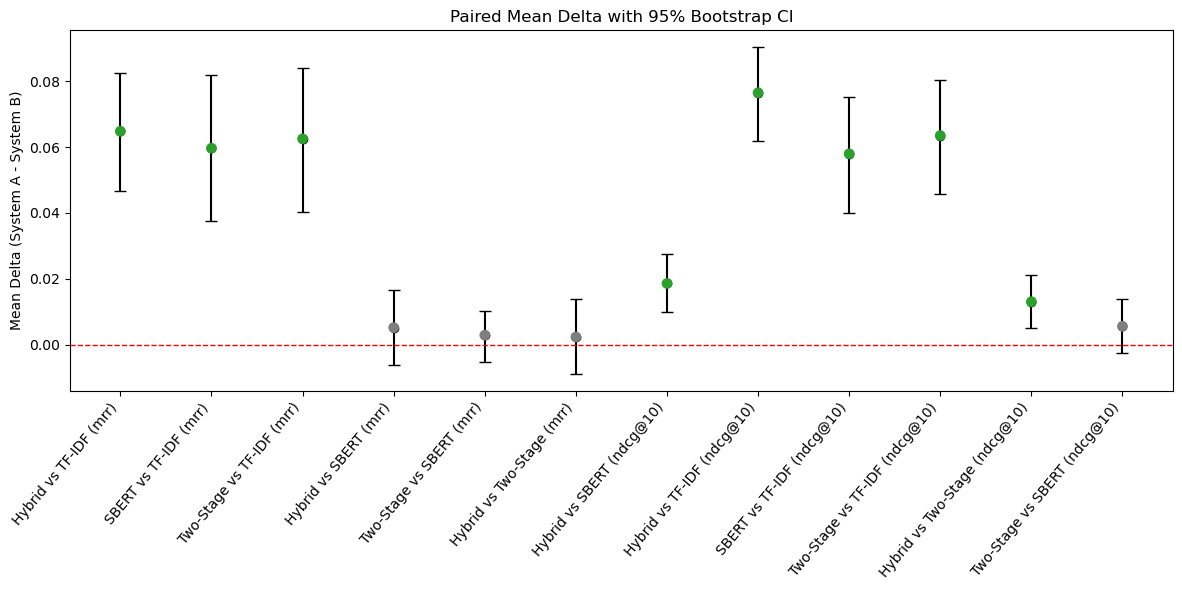

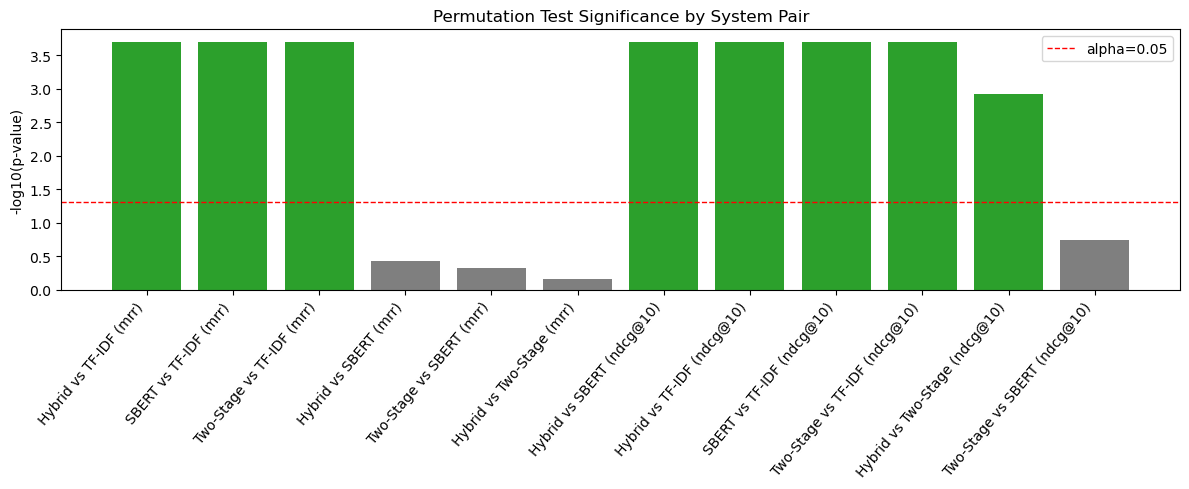

Saved significance figures to outputs/figures/significance_mean_delta_ci.png and outputs/figures/significance_pvalues.png


In [37]:
# Plot significance outputs (mean delta with 95% CI and permutation p-values)
if "significance_df" in globals() and isinstance(significance_df, pd.DataFrame):
    sig_plot_df = significance_df.copy()
else:
    sig_plot_df = pd.read_csv(os.path.join(METRICS_DIR, "significance_tests_ndcg10_mrr.csv"))

sig_plot_df["comparison"] = sig_plot_df["system_a"] + " vs " + sig_plot_df["system_b"] + " (" + sig_plot_df["metric"] + ")"
sig_plot_df = sig_plot_df.sort_values(["metric", "p_value_permutation", "comparison"]).reset_index(drop=True)

# Figure 1: Mean delta with 95% CI
plt.figure(figsize=(12, 6))
x = np.arange(len(sig_plot_df))
mean_delta = sig_plot_df["mean_delta_a_minus_b"].values
lower_err = mean_delta - sig_plot_df["ci95_low"].values
upper_err = sig_plot_df["ci95_high"].values - mean_delta

colors = ["tab:green" if s else "tab:gray" for s in sig_plot_df["is_significant_at_0_05"]]
plt.errorbar(
    x,
    mean_delta,
    yerr=[lower_err, upper_err],
    fmt="o",
    ecolor="black",
    capsize=4,
    color="black",
)
plt.scatter(x, mean_delta, c=colors, s=45, zorder=3)
plt.axhline(0, color="red", linestyle="--", linewidth=1)
plt.xticks(x, sig_plot_df["comparison"], rotation=50, ha="right")
plt.ylabel("Mean Delta (System A - System B)")
plt.title("Paired Mean Delta with 95% Bootstrap CI")
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, "significance_mean_delta_ci.png"), dpi=300)
plt.show()
plt.close()

# Figure 2: Permutation p-values as -log10(p)
plt.figure(figsize=(12, 5))
p_values = np.clip(sig_plot_df["p_value_permutation"].values.astype(float), 1e-12, 1.0)
neglogp = -np.log10(p_values)
threshold = -np.log10(0.05)

plt.bar(sig_plot_df["comparison"], neglogp, color=colors)
plt.axhline(threshold, color="red", linestyle="--", linewidth=1, label="alpha=0.05")
plt.xticks(rotation=50, ha="right")
plt.ylabel("-log10(p-value)")
plt.title("Permutation Test Significance by System Pair")
plt.legend(loc="upper right")
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, "significance_pvalues.png"), dpi=300)
plt.show()
plt.close()

print("Saved significance figures to outputs/figures/significance_mean_delta_ci.png and outputs/figures/significance_pvalues.png")

### 8.3 Embedding Geometry Analysis

Running embedding geometry analysis...


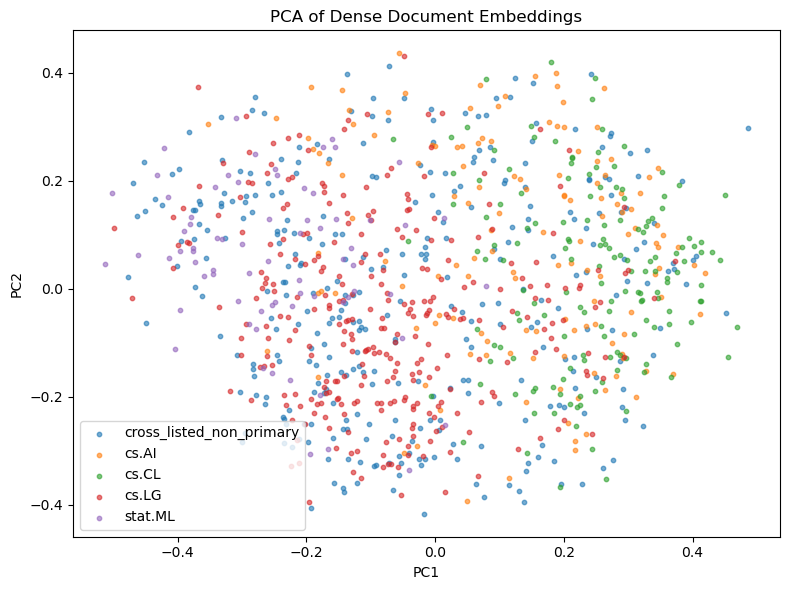

In [38]:
print("Running embedding geometry analysis...")
plot_dense_embedding_geometry(index, cleaned_papers)